In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("Lung_Disease_Dataset.csv")
df.columns = df.columns.str.strip()

print(df.head())

   Unnamed: 0   ID  AGE  PackHistory COPDSEVERITY   MWT1   MWT2  MWT1Best  \
0           1   58   77         60.0       SEVERE  120.0  120.0     120.0   
1           2   57   79         50.0     MODERATE  165.0  176.0     176.0   
2           3   62   80         11.0     MODERATE  201.0  180.0     201.0   
3           4  145   56         60.0  VERY SEVERE  210.0  210.0     210.0   
4           5  136   65         68.0       SEVERE  204.0  210.0     210.0   

   FEV1  FEV1PRED  ...   SGRQ  AGEquartiles  copd  gender  smoking  Diabetes  \
0  1.21      36.0  ...  69.55             4     3       1        2         1   
1  1.09      56.0  ...  44.24             4     2       0        2         1   
2  1.52      68.0  ...  44.09             4     2       0        2         1   
3  0.47      14.0  ...  62.04             1     4       1        2         0   
4  1.07      42.0  ...  75.56             1     3       1        2         0   

   muscular  hypertension  AtrialFib  IHD  
0         0 

In [26]:
# Drop unnecessary columns
df.drop(['Unnamed: 0', 'ID'], axis=1, inplace=True)

# Remove leakage column
df.drop(['copd'], axis=1, inplace=True)

# Drop weak/low-impact features (MOVE HERE — correct place)
df.drop(['AGEquartiles', 'IHD', 'hypertension'], axis=1, inplace=True)

# Encode target
df['COPDSEVERITY'] = df['COPDSEVERITY'].map({
    'MILD': 0,
    'MODERATE': 1,
    'SEVERE': 2,
    'VERY SEVERE': 3
})

# Handle imbalance (IMPORTANT)
df['COPDSEVERITY'] = df['COPDSEVERITY'].replace(3, 2)

print(df['COPDSEVERITY'].value_counts())

COPDSEVERITY
1    43
2    35
0    23
Name: count, dtype: int64


In [27]:
X = df.drop('COPDSEVERITY', axis=1)
y = df['COPDSEVERITY']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

In [30]:
scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [31]:
print(X_train.shape)
print(y_train.unique())

(80, 17)
[1 2 0]


In [32]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        num_class=3,   # IMPORTANT: because you merged class 3 → 2
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        max_depth=3,
        num_leaves=10,
        learning_rate=0.05,
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.89      0.89      0.89         9
           2       0.88      1.00      0.93         7

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.91      0.90      0.90        21


XGBoost
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00         7

    accuracy                           0.95        21
   macro avg       0.97      0.93      0.95        21
weighted avg       0.96      0.95      0.95        21

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] N

In [33]:
best_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...)

In [34]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00         7

    accuracy                           0.95        21
   macro avg       0.97      0.93      0.95        21
weighted avg       0.96      0.95      0.95        21



In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(best_model, X, y, cv=skf, scoring='f1_macro')

print("F1 Scores:", scores)
print("Mean F1:", scores.mean())

F1 Scores: [0.9454191  1.         0.93483709 0.89166667 0.83562092]
Mean F1: 0.9215087555490031


<Axes: >

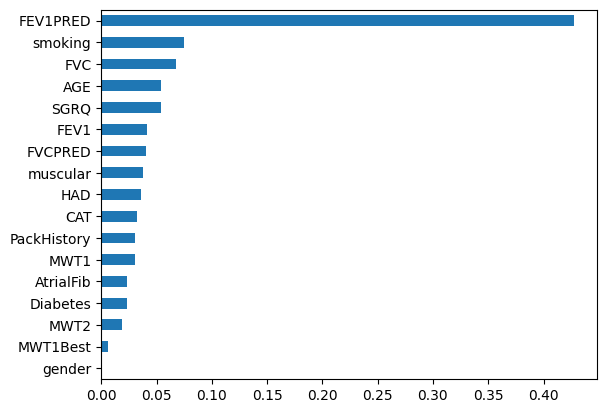

In [36]:
import pandas as pd

feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_macro')

print("Pipeline CV F1:", scores.mean())

Pipeline CV F1: 0.9323051091781741


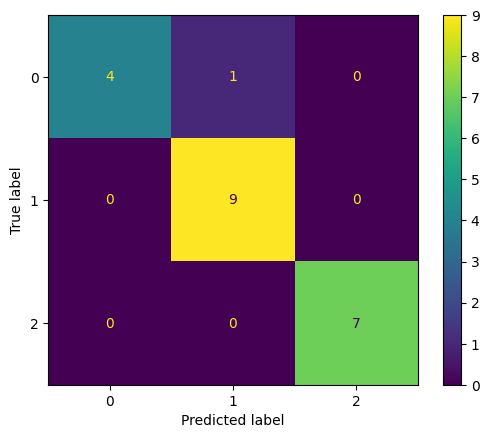

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

In [39]:
probs = best_model.predict_proba(X_test)

print("Sample Probabilities:")
print(probs[:5])

Sample Probabilities:
[[0.0034116  0.0160441  0.98054427]
 [0.03420686 0.94736135 0.01843181]
 [0.00212126 0.00394202 0.9939367 ]
 [0.03555626 0.954872   0.00957169]
 [0.04698626 0.9342605  0.0187533 ]]


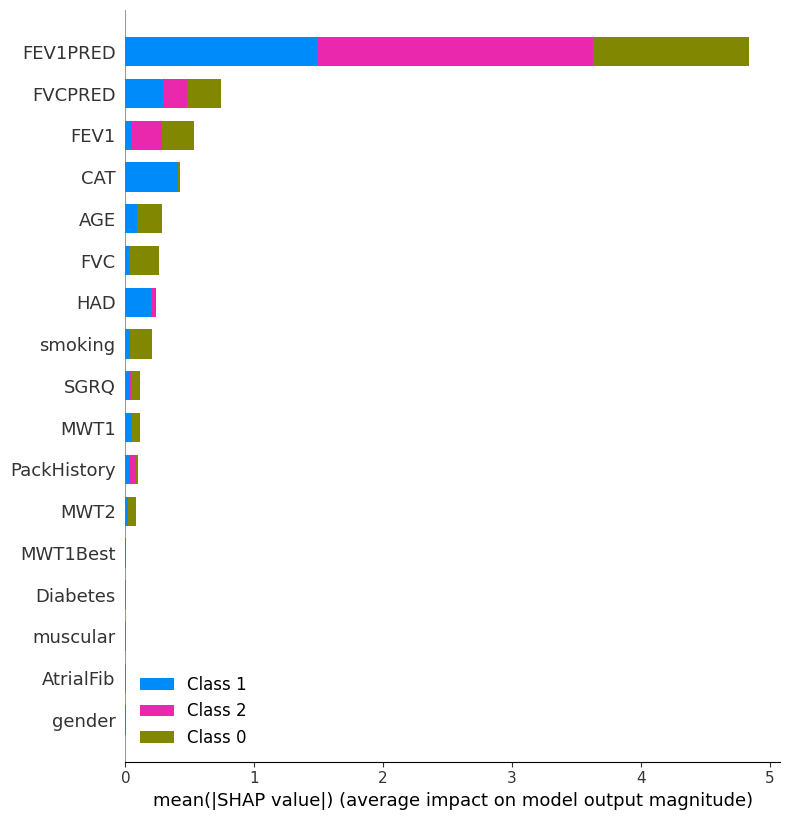

In [40]:
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [41]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(best_model, threshold="median")
selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4,5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100,200]
}

grid = GridSearchCV(
    XGBClassifier(objective='multi:softprob', num_class=3),
    param_grid,
    cv=3,
    scoring='f1_macro'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.71      0.56      0.62         9
           2       0.83      0.71      0.77         7

    accuracy                           0.71        21
   macro avg       0.72      0.76      0.72        21
weighted avg       0.73      0.71      0.71        21



In [44]:
import joblib
joblib.dump(best_model, "lung_model.pkl")

['lung_model.pkl']

In [45]:
import pickle

# Save model
with open("Lung.pkl", "wb") as file:
    pickle.dump(model, file)

In [46]:
from google.colab import files

files.download("Lung.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>